 EDA

In this analysis of the Brazilian e-commerce data set, attempted to understand various aspects of the online business environment. Analyzed the trends in the online business environment, identified the successful product categories in the online business environment, and assessed the level of customer satisfaction in the online business environment. It is evident that the data provides valuable information about the online business environment. On a final note, this analysis of the online business environment in Brazil highlights the importance of data-driven decision-making in the e-commerce industry.

In [93]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
# Load the datasets

customers = pd.read_csv('clean_data\customers_cleaned.csv')
orders = pd.read_csv('clean_data\orders_cleaned.csv')
products = pd.read_csv('clean_data\cleaned_products_final.csv')
order_items = pd.read_csv('clean_data\order_items_cleaned.csv')
sellers = pd.read_csv('clean_data\sellers.csv')
order_reviews = pd.read_csv('clean_data\order_reviews_cleaned.csv')
order_payments = pd.read_csv('clean_data\order_payments_cleaned.csv')
geolocation = pd.read_csv('clean_data\geolocation_cleaned.csv')
marketing_leads = pd.read_csv('clean_data\marketing_leads_cleaned.csv')
closed_deals = pd.read_csv('clean_data\closed_deals_cleaned.csv')
category_translation = pd.read_csv('clean_data\category_translation_cleaned.csv')


<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:13: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\o'
<>:9: SyntaxWarning: invalid escape sequence '\o'
<>:10: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence

Labeling comumns:

**Numeric Columns** - price, freight_value, total_value, payment_sequential, payment_installments,  payment_value, review_score, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm, geolocation_lat, geolocation_lng, declared_monthly_revenue	declared_product_catalog_size.

**Categorical Columns** - customer_zip_code_prefix, customer_city, customer_state,order_status, 	is_delivered, is_canceled, order_item_id, payment_type, review_score, review_comment_title, review_comment_message, review_category, product_category_name, weight_category, size_category, product_category_name_english, geolocation_zip_code_prefix, geolocation_city, geolocation_state, seller_zip_code_prefix, seller_city, seller_state, origin, business_segment, lead_type, lead_behaviour_profile, has_company, has_gtin, average_stock, business_type,	declared_product_catalog_size.	

**Mixed Columns** - customer_id, customer_unique_id, order_id, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date, 	delivery_time, order_estimated_delivery_time, order_shipping_time, order_processing_time, order_transit_time, product_id, seller_id, shipping_limit_date, review_id, 	review_creation_date, review_answer_timestamp, feedback_timestamp, mql_id, first_contact_date, landing_page_id, sdr_id, sr_id, won_date.

In [95]:
closed_deals.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue,declared_product_catalog_size
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,Pet,Online_Medium,Cat,False,False,Unknown,Reseller,NaN,0.0,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,Car_Accessories,Industry,Eagle,False,False,Unknown,Reseller,NaN,0.0,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,Home_Appliances,Online_Big,Cat,False,False,Unknown,Reseller,NaN,0.0,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,Food_Drink,Online_Small,Unknown,False,False,Unknown,Reseller,NaN,0.0,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,Home_Appliances,Industry,Wolf,False,False,Unknown,Manufacturer,NaN,0.0,0.0


Order_items table 

In [96]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04


In [97]:
items_per_order = order_items.groupby('order_id')['order_item_id'].count()
items_per_order.value_counts().sort_index()
# Most orders have 1 item, but some have up to 5 or more.

order_item_id
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
20        2
21        1
Name: count, dtype: int64

In [98]:
order_items['seller_id'].nunique()

3095

In [ ]:

order_items['seller_id'].value_counts().head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: count, dtype: int64

In [100]:
order_items.groupby('product_id')['total_value'].sum().sort_values(ascending=False).head(10)
# top 10 most profitable products

product_id
bb50f2e236e5eea0100680137654686c    67606.10
d1c427060a0f73f6b889a5c7c61f2ac4    60976.03
6cdd53843498f92890544667809f1595    59093.99
99a4788cb24856965c36a24e339b6058    51071.60
d6160fb7873f184099d9bc95e30376af    50326.18
3dd2a17168ec895c781a9191c1e95ad7    48212.22
aca2eb7d00ea1a7b8ebd4e68314663af    44820.76
5f504b3a1c75b73d6151be81eb05bdc9    41725.81
25c38557cf793876c5abdd5931f922db    40311.95
53b36df67ebb7c41585e8d54d6772e08    39957.93
Name: total_value, dtype: float64

In [101]:
order_items['product_id'].value_counts().head(10)
# top 10 most selling products

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64

In [102]:
order_items.groupby('order_id')['total_value'].sum().sort_values(ascending=False).head(10)
# top 10 most expensive orders

order_id
03caa2c082116e1d31e67e9ae3700499    13664.08
736e1922ae60d0d6a89247b851902527     7274.88
0812eb902a67711a1cb742b3cdaa65ae     6929.31
fefacc66af859508bf1a7934eab1e97f     6922.21
f5136e38d1a14a4dbd87dff67da82701     6726.66
2cc9089445046817a7539d90805e6e5a     6081.54
a96610ab360d42a2e5335a3998b4718a     4950.34
b4c4b76c642808cbe472a32b86cddc95     4809.44
199af31afc78c699f0dbf71fb178d4d4     4764.34
8dbc85d1447242f3b127dda390d56e19     4681.78
Name: total_value, dtype: float64

In [103]:
order_items.groupby('seller_id')['total_value'].sum().sort_values(ascending=False).head(10)
# top 10 sellers by total sales

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    249640.70
7c67e1448b00f6e969d365cea6b010ab    239536.44
53243585a1d6dc2643021fd1853d8905    235856.68
4a3ca9315b744ce9f8e9374361493884    235539.96
fa1c13f2614d7b5c4749cbc52fecda94    204084.73
da8622b14eb17ae2831f4ac5b9dab84a    185192.32
7e93a43ef30c4f03f38b393420bc753a    182754.05
1025f0e2d44d7041d6cf58b6550e0bfa    172860.69
7a67c85e85bb2ce8582c35f2203ad736    162648.38
955fee9216a65b617aa5c0531780ce60    160602.68
Name: total_value, dtype: float64

In [104]:
order_items['freight_ratio'] = (order_items['freight_value'] / order_items['price'])*100
order_items['freight_ratio'].describe()

count    112650.000000
mean         32.086355
std          34.989368
min           0.000000
25%          13.403366
50%          23.135624
75%          39.303621
max        2623.529412
Name: freight_ratio, dtype: float64

In [105]:
(order_items['freight_value'] > order_items['price']).sum()

4124

In [106]:
(order_items['freight_value'] > order_items['price']).mean() * 100

3.6608965823346646

In [107]:
order_items.sort_values(by='freight_ratio', ascending=False).head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_value,freight_ratio
87081,c5bdd8ef3c0ec420232e668302179113,2,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-07 02:55:22,0.85,22.30,23.15,2623.529412
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23,19.08,2144.705882
48625,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23,19.08,2144.705882
110535,fb265b2dc558a56445dfc48f8224e201,1,baf25ed4f8f70238cc87230379471454,128f9bfbe4c7d5185033914b1de3d39a,2017-10-18 21:35:15,9.90,121.22,131.12,1224.444444
94495,d642656598ae928a250620315d19e87e,1,b07fffe072c9adc235a35d8da7c0584d,dd533b429f380718b70ad9922c294bae,2018-03-13 10:55:37,4.99,37.04,42.03,742.284569


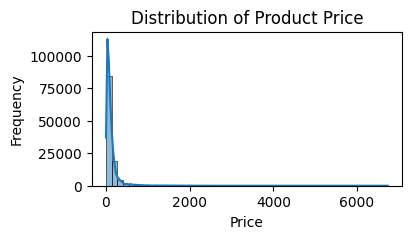

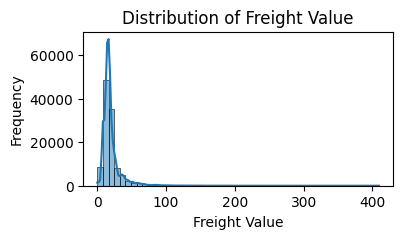

In [108]:
plt.figure(figsize=(4,2))
sns.histplot(order_items['price'], bins=50, kde=True)

plt.title('Distribution of Product Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.figure(figsize=(4,2))
sns.histplot(order_items['freight_value'], bins=50, kde=True)

plt.title('Distribution of Freight Value')
plt.xlabel('Freight Value')
plt.ylabel('Frequency')


plt.show()

Conclosion:
Price distribution is right-skewed
Most products priced below 200 BRL
Most freight values are 10–40 BRL

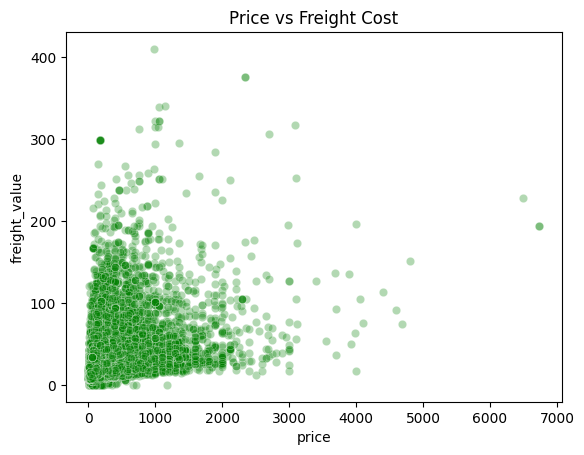

In [109]:
sns.scatterplot( x="price",y="freight_value",data=order_items, alpha=0.3, color = 'green')
plt.title("Price vs Freight Cost")
plt.show()

# Expensive products tend to have higher freight costs.

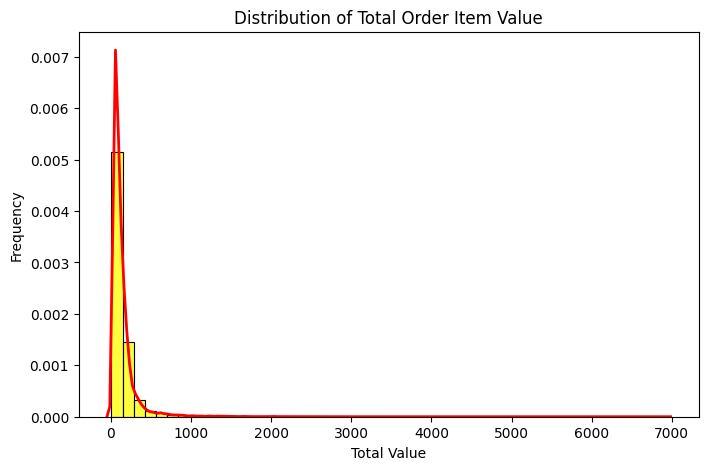

In [247]:
plt.figure(figsize=(8,5))

sns.histplot(order_items['total_value'], bins=50, color='yellow', stat = 'density')

sns.kdeplot(order_items['total_value'], color='red', linewidth=2)

plt.title('Distribution of Total Order Item Value')
plt.xlabel('Total Value')
plt.ylabel('Frequency')

plt.show()

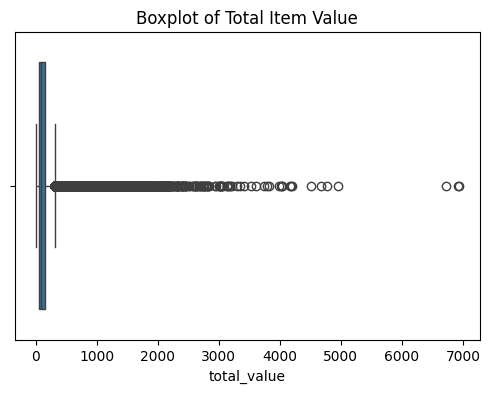

In [111]:
plt.figure(figsize=(6,4))
sns.boxplot(x=order_items['total_value'])

plt.title('Boxplot of Total Item Value')

plt.show()

In [112]:
order_items[['price','freight_value','total_value']].skew()

price            7.923208
freight_value    5.639870
total_value      7.686087
dtype: float64

In [113]:

order_items[['price','freight_value','total_value']].quantile([0.25,0.5,0.75,0.90,0.95,0.99])

,price,freight_value,total_value
0.25,39.90,13.080,55.2200
0.50,74.99,16.260,92.3200
0.75,134.90,21.150,157.9375
0.90,229.80,34.041,257.5610
0.95,349.90,45.120,378.9595
0.99,890.00,84.520,923.2159


conclusion :
The analysis of price, freight_value, and total_value (price + freight_value) shows that most products in the dataset are low to moderately priced, while a small number of items have very high prices, creating a right-skewed distribution. Shipping costs are generally much lower than product prices, though a few orders have unusually high freight values. As a result, the total order value is also right-skewed, indicating that most purchases are relatively inexpensive while a small number of high-value transactions act as outliers.
The dataset contains several high-value outliers in price and freight cost. These likely represent expensive products or long-distance deliveries. Since they reflect real business transactions, they are retained for further analysis, though log transformation may be used to better visualize the distribution.
Approximately 3.5% of orders have freight costs higher than product prices. This is likely due to very low-priced products where shipping costs dominate the total order value. These cases are retained in the dataset as they represent real marketplace behavior.
Approximately 3.5% of orders have freight costs higher than product prices. This is likely due to very low-priced products where shipping costs dominate the total order value. These cases are retained in the dataset as they represent real marketplace behavior.
The analysis of the order_items table shows that a small number of products and sellers generate a large share of total revenue, indicating an uneven distribution of sales on the platform. Most orders contain only one item, while multi-item orders are relatively less common. Additionally, products with the highest sales volume are not always the ones generating the highest revenue, showing that both product price and sales quantity influence overall revenue.



order payments table

In [114]:
order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [115]:
order_payments['payment_value'].sum()
# Total revenue (2016-2018)

16008872.12

In [116]:
order_payments['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

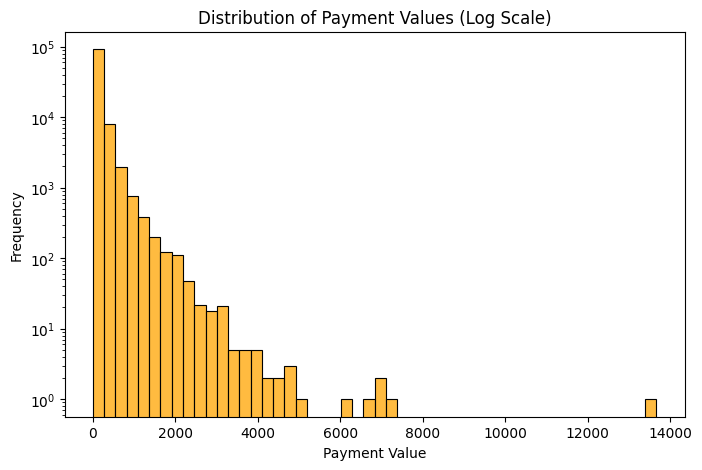

In [117]:
plt.figure(figsize=(8,5))
sns.histplot(order_payments['payment_value'], bins=50, color = 'orange')

plt.yscale('log')

plt.title('Distribution of Payment Values (Log Scale)')
plt.xlabel('Payment Value')
plt.ylabel('Frequency')

plt.show()

#payment data is skewed with many small transactions and few large ones,
#  the log scale helps reveal patterns across both common and rare payment ranges.

In [118]:
bins = [0, 300, 600, order_payments['payment_value'].max()]
labels = ['Small', 'Medium', 'Large']

order_payments['payment_size'] = pd.cut(order_payments['payment_value'], bins=bins, labels=labels)

In [119]:
revenue_share = order_payments.groupby('payment_size')['payment_value'].sum()

revenue_percent = revenue_share / revenue_share.sum() * 100

revenue_percent

payment_size
Small     61.450259
Medium    17.481998
Large     21.067743
Name: payment_value, dtype: float64

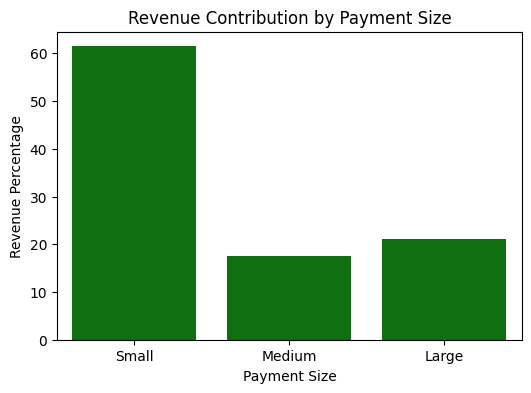

In [120]:
plt.figure(figsize=(6,4))
sns.barplot(x=revenue_percent.index, y=revenue_percent.values, color = 'green')


plt.title('Revenue Contribution by Payment Size')
plt.xlabel('Payment Size')
plt.ylabel('Revenue Percentage')

plt.show()

In [121]:
order_payments['payment_type'].value_counts(normalize=True)*100
# Almost 74 % of payment type dominated by credit card

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64

In [122]:
order_payments.groupby('payment_installments')['payment_value'].mean().sort_values()
# Orders with higher payment values tend to use more installments, 
# suggesting that installment options encourage customers to make higher-value purchases.

payment_installments
0      94.315000
1     112.420229
11    124.932174
2     127.228150
3     142.539317
13    150.462500
4     163.976840
14    167.962667
17    174.602500
5     183.465222
7     187.673672
9     203.440870
6     209.849952
22    228.710000
23    236.480000
21    243.700000
16    292.694000
8     307.737427
12    321.678496
10    415.085837
15    445.553108
18    486.483333
24    610.048889
20    615.801765
Name: payment_value, dtype: float64

In [123]:
order_payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)
# most revenew generating payment method

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

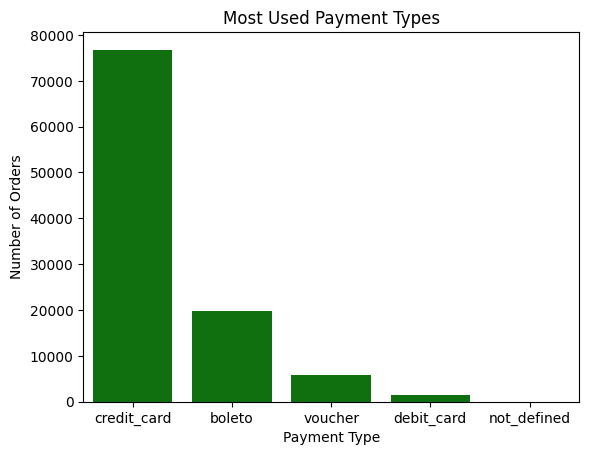

In [124]:
sns.countplot(x='payment_type', data=order_payments, color = 'green')

plt.title("Most Used Payment Types")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.show()

In [125]:
order_payments['payment_installments'].value_counts().sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [126]:
order_payments.groupby('payment_installments')['payment_value'].sum()

payment_installments
0         188.63
1     5907233.36
2     1579283.03
3     1491103.80
4     1163907.61
5      961174.30
6      822611.81
7      305157.39
8     1313423.34
9      131015.92
10    2211577.34
11       2873.44
12      42783.24
13       2407.40
14       2519.44
15      32970.93
16       1463.47
17       1396.82
18      13135.05
20      10468.63
21        731.10
22        228.71
23        236.48
24      10980.88
Name: payment_value, dtype: float64

In [127]:
order_payments[order_payments['payment_installments'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_size
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69,Small
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94,Small


In [128]:
order_payments['payment_installments'] = order_payments['payment_installments'].replace(0, 1)
# Since 2 people paid in 0 installments, but in 2 payment_sequal we will assume they paid in 1 installment to avoid issues with analysis.

Conclusion
The analysis of the order_payments table shows that credit cards dominate payment methods, accounting for 74% of transactions. Most payments are relatively small, with over 60% of total revenue coming from orders valued between 0–300 R$, while larger payments are less frequent. Installment payments are commonly used for higher-value orders, indicating that installment options help customers make larger purchases. Overall, revenue is moderately concentrated, and the dataset highlights typical customer payment behavior in the marketplace.


Orders table

In [129]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,order_estimated_delivery_time,order_shipping_time,order_processing_time,order_transit_time,is_delivered,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8 days 10:28:40,15 days 13:03:27,2 days 08:47:45,0 days 00:10:42,6 days 01:30:13,True,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13 days 18:46:08,19 days 03:18:23,0 days 11:06:33,1 days 06:42:50,12 days 00:56:45,True,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 09:27:40,26 days 15:21:11,0 days 04:54:37,0 days 00:16:34,9 days 04:16:29,True,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13 days 05:00:36,26 days 04:31:54,3 days 17:54:00,0 days 00:17:53,9 days 10:48:43,True,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2 days 20:58:23,12 days 02:41:21,0 days 21:26:05,0 days 01:01:50,1 days 22:30:28,True,False


In [130]:
#orders table

#Changing date datatype

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors='coerce')
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors='coerce')
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors='coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors='coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors='coerce')

In [131]:
# calculating delivery time
orders['delivery_time'] = orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
orders['order_estimated_delivery_time'] = orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']
orders['order_shipping_time'] = orders['order_delivered_carrier_date'] - orders['order_approved_at']
orders['order_processing_time'] = orders['order_approved_at'] - orders['order_purchase_timestamp']
orders['order_transit_time'] = orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']
orders['approval_time'] = ( orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds()/3600
orders['delivery_delay'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

In [132]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype          
---  ------                         --------------  -----          
 0   order_id                       99441 non-null  str            
 1   customer_id                    99441 non-null  str            
 2   order_status                   99441 non-null  str            
 3   order_purchase_timestamp       99441 non-null  datetime64[us] 
 4   order_approved_at              99281 non-null  datetime64[us] 
 5   order_delivered_carrier_date   97658 non-null  datetime64[us] 
 6   order_delivered_customer_date  96476 non-null  datetime64[us] 
 7   order_estimated_delivery_date  99441 non-null  datetime64[us] 
 8   delivery_time                  96476 non-null  timedelta64[us]
 9   order_estimated_delivery_time  99441 non-null  timedelta64[us]
 10  order_shipping_time            97644 non-null  timedelta64[us]
 11  order_process

In [133]:
orders['order_status'].value_counts

<bound method IndexOpsMixin.value_counts of 0        delivered
1        delivered
2        delivered
3        delivered
4        delivered
           ...    
99436    delivered
99437    delivered
99438    delivered
99439    delivered
99440    delivered
Name: order_status, Length: 99441, dtype: str>

In [134]:
orders['order_status'].value_counts(normalize=True)*100
# Most orders are delivered, but a significant portion are canceled or in transit,
#  which could impact customer satisfaction and revenue.

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

In [135]:
(orders['delivery_time'].dt.days > 60).sum()/orders['delivery_time'].dt.days.count() * 100
# About 0.5% of orders took more than 60 days to deliver, which could indicate potential issues with logistics or customer satisfaction.
# Need to check location for these orders to see if they are concentrated in certain areas. 


0.2985198391309756

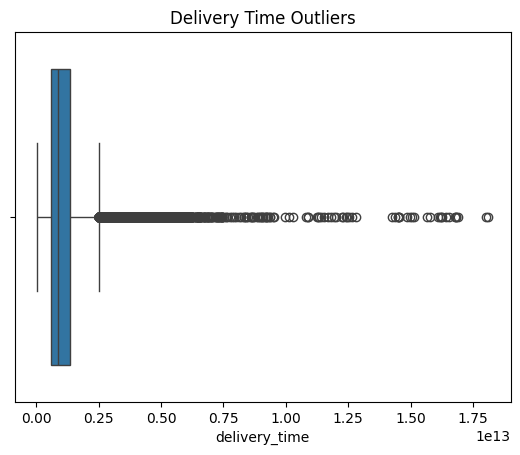

In [136]:
sns.boxplot(x=orders['delivery_time'])
plt.title("Delivery Time Outliers")
plt.show()

# There are some extreme outliers in delivery time, with a few orders taking over 100 days to deliver. These outliers could be due to logistical issues, lost packages, or data entry errors and may warrant further investigation.

In [137]:
(orders['delivery_delay'] > 0).mean()*100

6.571736004263835

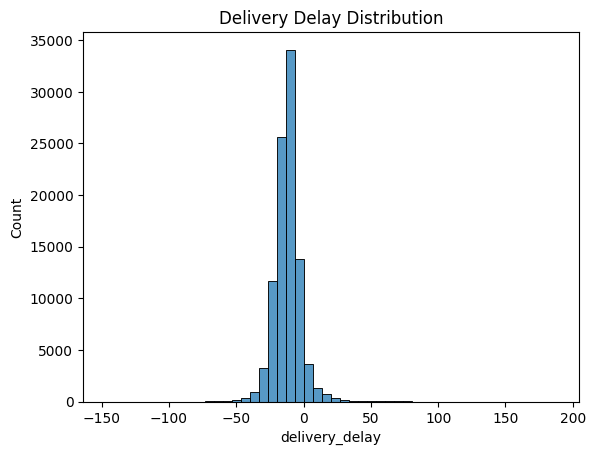

In [138]:
sns.histplot(orders['delivery_delay'], bins=50)
plt.title("Delivery Delay Distribution")
plt.show()

# most of the orders delivered on time or early

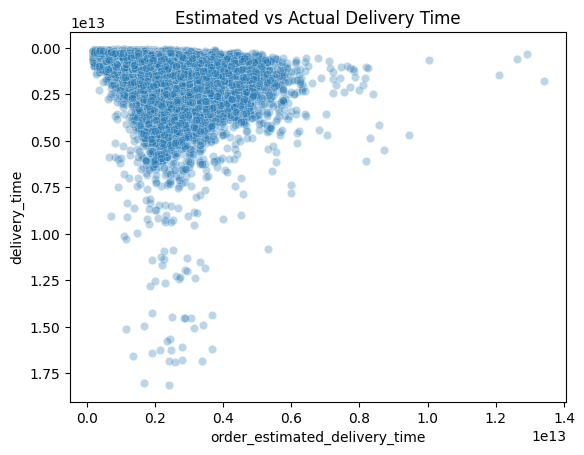

In [139]:
sns.scatterplot(
    x=orders['order_estimated_delivery_time'],
    y=orders['delivery_time'],
    alpha=0.3
)
plt.title("Estimated vs Actual Delivery Time")
plt.show()


<Axes: xlabel='purchase_month'>

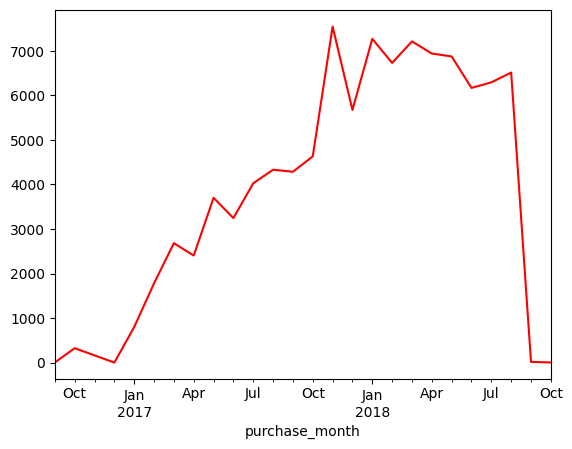

In [140]:
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders.groupby('purchase_month')['order_id'].count().plot(kind='line', color = 'red' )

# There is a clear seasonal pattern in order volume, with peaks around November and December, likely due to holiday shopping. There is also a noticeable dip in mid-2017, which could be due to external factors affecting consumer behavior.

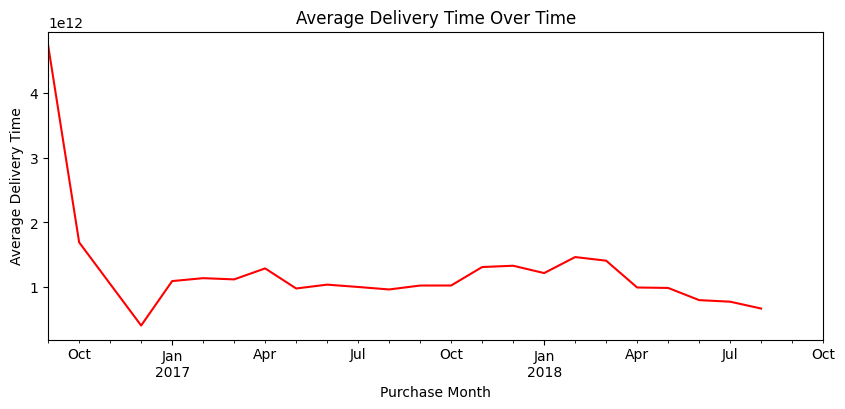

In [141]:
orders.groupby('purchase_month')['delivery_time'].mean().plot(figsize=(10,4), color = 'red')
plt.title("Average Delivery Time Over Time")
plt.xlabel("Purchase Month")
plt.ylabel("Average Delivery Time")
plt.show()

# There is a slight increase in average delivery time during certain months, which could be due to seasonal demand or logistical challenges.

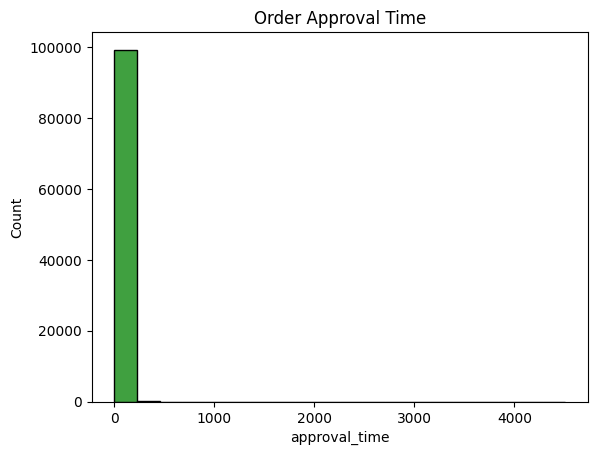

In [142]:
sns.histplot(orders['approval_time'], bins=20, color = 'green')
plt.title("Order Approval Time")
plt.show()
# Most orders are approved within a few hours, but there are some outliers with much longer approval times, which could indicate issues with payment processing or fraud checks.

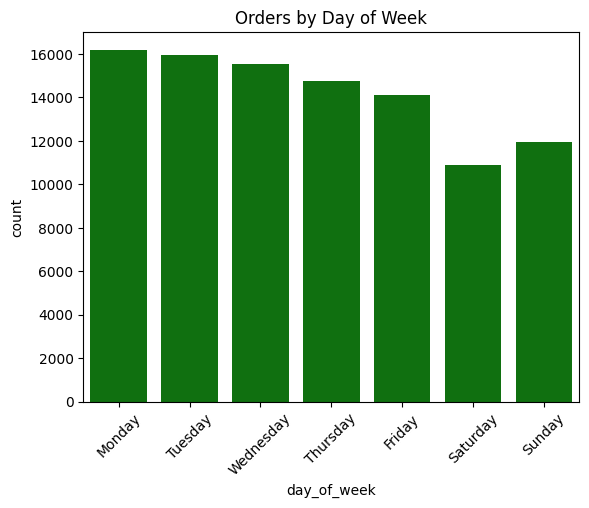

In [143]:
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()

sns.countplot(data=orders, x='day_of_week',
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'], color = 'green')

plt.xticks(rotation=45)
plt.title("Orders by Day of Week")
plt.show()

# Customers are most active on weekdays, weekend shopping activity is lower.

Conclusion:
Most orders (≈97%) are successfully delivered, with a small fraction cancelled or still processing. A  portion (≈0.5–1%) of deliveries took over two months, while overall delivery delays are low (≈6.5%), and most orders are delivered on time. Order approval is generally very fast. Sales show a slight upward trend over months, reflecting seasonal demand, and weekday purchases are higher than weekend orders.

Products table

In [144]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,weight_category,size_category,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,light,medium,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,medium,large,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,light,medium,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,medium,medium,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,medium,medium,housewares


In [145]:
products['product_category_name_english'].value_counts().head(10)
# The top 10 product categories are dominated by electronics and fashion items, which suggests that these categories are key drivers of sales on the platform. 

product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: count, dtype: int64

In [146]:
products['weight_category'].value_counts()

weight_category
heavy      12892
medium     11285
light       8772
unknown        2
Name: count, dtype: int64

Text(0, 0.5, 'products_counts')

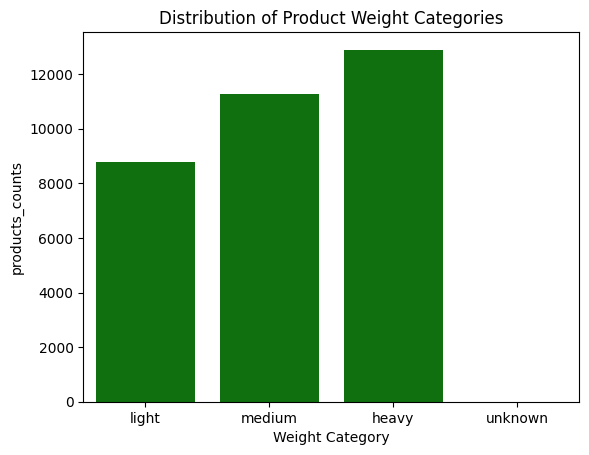

In [147]:
sns.countplot(x='weight_category', data=products, color = 'green')
plt.title("Distribution of Product Weight Categories")
plt.xlabel("Weight Category")
plt.ylabel('products_counts')
# Maximum numbers of products are heavy

In [148]:
products['size_category'].value_counts()

size_category
medium     17983
large      12754
small       2212
unknown        2
Name: count, dtype: int64

Text(0, 0.5, 'products_counts')

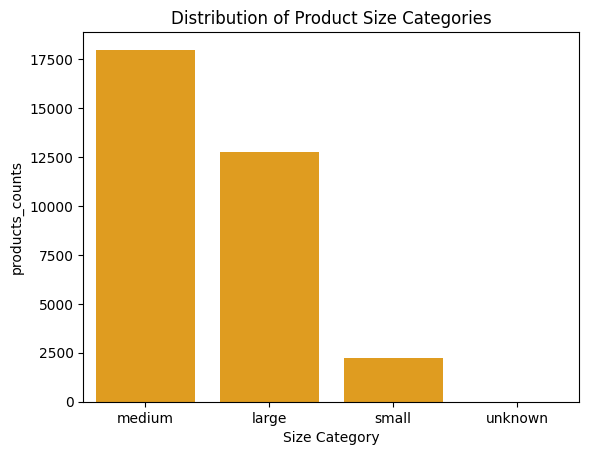

In [149]:
sns.countplot(x='size_category', data=products, color = 'orange')
plt.title("Distribution of Product Size Categories")
plt.xlabel("Size Category")
plt.ylabel('products_counts')

# Maximum numbers of products are medium size, followed by small and large.

Conclusion:
The analysis shows that the top three product categories by product count are cama_mesa_banho, esporte_lazer, and moveis_decoracao. These categories contain the largest number of listed products in the dataset. Additionally, many of these products tend to be relatively heavier and mostly fall within the medium size range.


Sellers table

In [150]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,Campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,Mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,Rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,Sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,Braganca paulista,SP


In [151]:
sellers['seller_id'].nunique()

3095

In [152]:
sellers['seller_city'].nunique()

611

In [153]:
sellers['seller_state'].nunique()

23

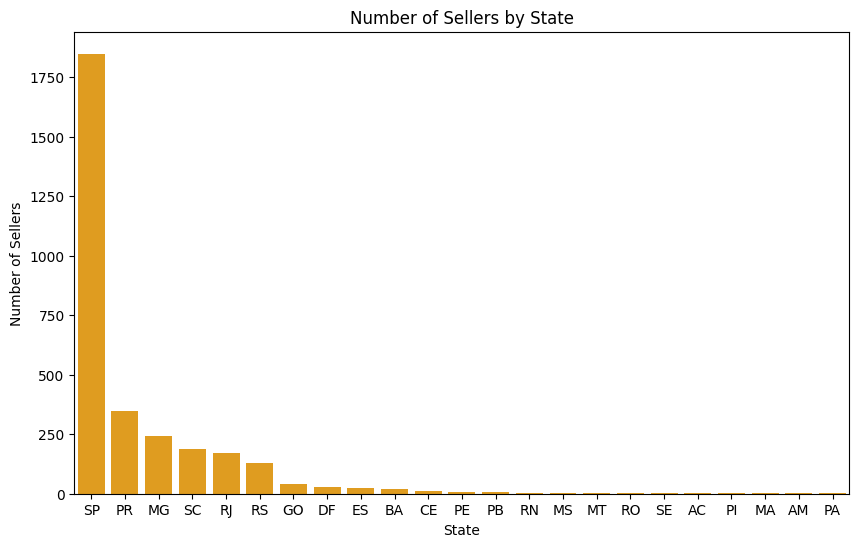

In [154]:
seller_state_count = sellers['seller_state'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=seller_state_count.index, y=seller_state_count.values, color = 'orange')

plt.title("Number of Sellers by State")
plt.xlabel("State")
plt.ylabel("Number of Sellers")
plt.show()

# Sellers are mostly concentrated in SP, followed by MG and RJ, which could indicate regional hubs for e-commerce activity in Brazil.


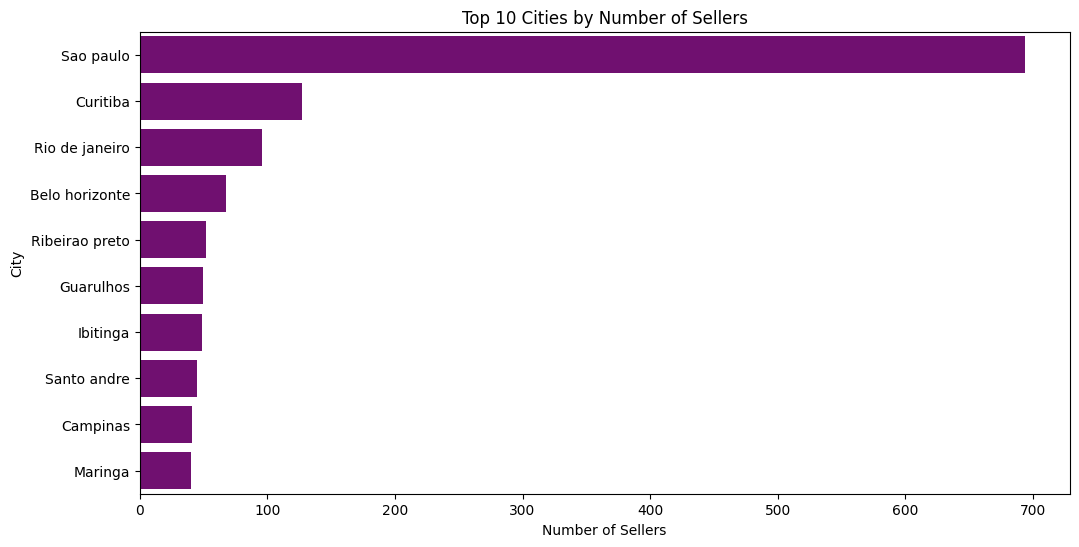

In [155]:
top_cities = sellers['seller_city'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_cities.values, y=top_cities.index,  color = 'purple')

plt.title("Top 10 Cities by Number of Sellers",)
plt.xlabel("Number of Sellers")
plt.ylabel("City")
plt.show()

# majority of sellers are from Sao Paulo, followed by Rio de Janeiro and Belo Horizonte, which is consistent with the distribution of customers and suggests that these cities are key markets for e-commerce in Brazil.

Conclusion:

The sellers table analysis shows that sellers are concentrated in a few Brazilian states, with São Paulo having the highest number of sellers. The marketplace is therefore geographically concentrated in major urban regions.


Order review table

In [156]:
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_category,feedback_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No Title,No Comments,2018-01-18 00:00:00,2018-01-18 21:46:59,Good,0 days 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No Title,No Comments,2018-03-10 00:00:00,2018-03-11 03:05:13,Very Good,1 days 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No Title,No Comments,2018-02-17 00:00:00,2018-02-18 14:36:24,Very Good,1 days 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No Title,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,Very Good,0 days 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No Title,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,Very Good,1 days 10:26:53


In [157]:
order_reviews['review_category'].value_counts()
# Most reviews are positive, but there is a significant portion of negative reviews that could indicate areas for improvement in customer satisfaction.

review_category
Very Good    57328
Bad          22754
Good         19142
Name: count, dtype: int64

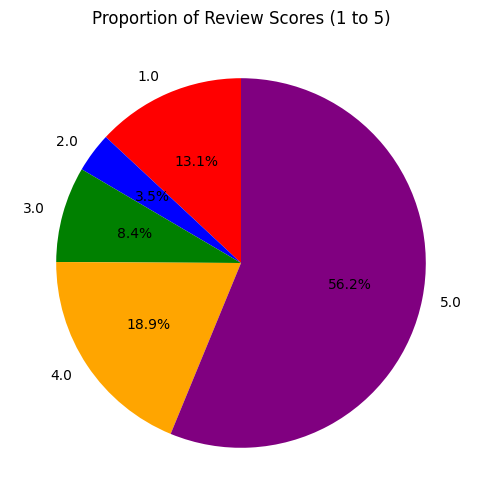

In [234]:
# Count of each review score
score_counts = review_analysis_df['review_score'].value_counts().sort_index()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    score_counts, 
    labels=score_counts.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=['red', 'blue', 'green', 'orange', 'purple']  # using color names
)
plt.title("Proportion of Review Scores (1 to 5)")
plt.show()


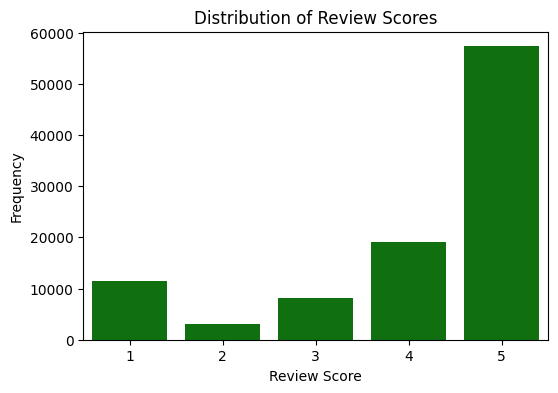

In [158]:
plt.figure(figsize=(6,4))
sns.countplot(x='review_score', data=order_reviews, color = 'green')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.show()

# The distribution of review scores is skewed towards positive ratings, with a majority of reviews being 5 stars. However, there are still a notable number of 1 and 2 star reviews, which could indicate issues with product quality or customer service that need to be addressed.

In [159]:
order_reviews[order_reviews['review_comment_message'] == 'No Comments'].value_counts().sum()/order_reviews['review_comment_message'].count()*100
# About 59% of reviews have no comments..

58.70253164556962

In [160]:
order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'], errors='coerce')
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'], errors='coerce')
order_reviews['feedback_timestamp'] = pd.to_timedelta(order_reviews['feedback_timestamp'], errors='coerce')
order_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   review_id                99224 non-null  str            
 1   order_id                 99224 non-null  str            
 2   review_score             99224 non-null  int64          
 3   review_comment_title     99224 non-null  str            
 4   review_comment_message   99224 non-null  str            
 5   review_creation_date     99224 non-null  datetime64[us] 
 6   review_answer_timestamp  99224 non-null  datetime64[us] 
 7   review_category          99224 non-null  str            
 8   feedback_timestamp       99224 non-null  timedelta64[us]
dtypes: datetime64[us](2), int64(1), str(5), timedelta64[us](1)
memory usage: 6.8 MB


In [161]:
order_reviews['feedback_timestamp'].describe()

count                     99224
mean     3 days 03:34:33.029700
std      9 days 21:21:40.258026
min             0 days 02:08:29
25%      1 days 00:07:00.750000
50%      1 days 16:11:55.500000
75%             3 days 02:29:08
max           518 days 16:46:52
Name: feedback_timestamp, dtype: object

In [162]:
order_reviews.sort_values(by='feedback_timestamp').head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_category,feedback_timestamp
49291,44cff23dc6c95bcfa3e8d23c0ef07c95,c870ef6a8e1d8eec841d79b42a6a20e4,3,No Title,Produto vazando.,2017-02-01,2017-02-01 02:08:29,Bad,0 days 02:08:29
83108,2fcff1e65580feb6ad3d7f26461b3693,51375acfdef4d742df94640aa60d385b,1,No Title,"Disponibilizam o produto no site do stark, por...",2017-11-08,2017-11-08 02:24:24,Bad,0 days 02:24:24
6676,4711ba3d2ef06df23afe7572fccf880a,978fe45a42f99b9534520c4a5d880af6,4,No Title,No Comments,2017-11-24,2017-11-24 02:25:19,Good,0 days 02:25:19
13330,702651556ae0188de7bf6ba84ddc54d2,628430cb4db23766c1cc5c9d232cf985,1,No Title,"Estou ha mais de 1 mes esperando meu produto, ...",2018-01-20,2018-01-20 02:26:13,Bad,0 days 02:26:13
95333,b364a4dc74c517baf2277195b93c426e,36543b4a82c2c12ec60edfe8b5f67e3c,1,No Title,Os produtos não foram entregues e só após exce...,2017-11-19,2017-11-19 02:27:17,Bad,0 days 02:27:17


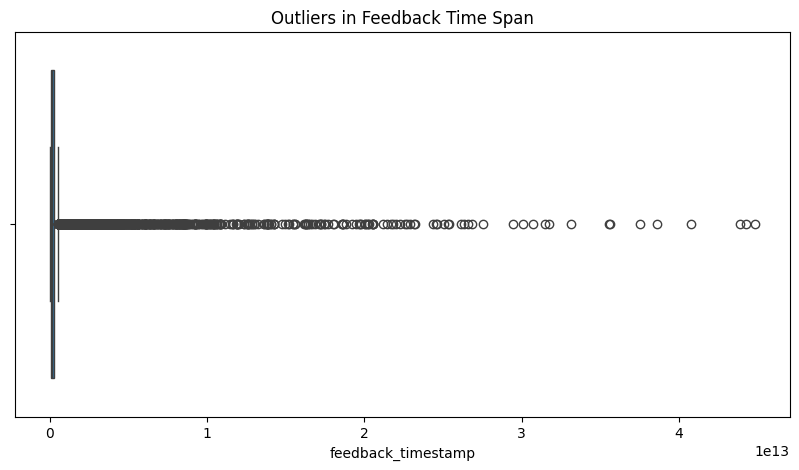

In [163]:
plt.figure(figsize=(10,5))
sns.boxplot(x=order_reviews['feedback_timestamp'])
plt.title("Outliers in Feedback Time Span")
plt.show()

# There are some extreme outliers in feedback time span, with a few reviews taking over 100 days to receive feedback. These outliers could be due to delayed responses from customer service or data entry errors.

Conclusion:
Most reviews are positive, with ratings of 4 or 5, indicating overall good customer satisfaction. However, a small number of 1 or 2 ratings suggest potential business or service issues. Around 59% of reviews contain no comments, so encouraging customers to leave written feedback could provide more valuable insights. Additionally, the feedback time span is highly skewed, with some extreme outliers—responses taking over 100 days, and a maximum of 518 days. These delays highlight an area where customer service response time could be improved to support better customer retention.

customers table

In [164]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,Franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,Sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,Sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,Mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,Campinas,SP


In [165]:

customers['customer_unique_id'].nunique()/customers['customer_id'].count()*100

# About 97% of customers are unique, indicating that there is very little repeated customers.

96.63619633752677

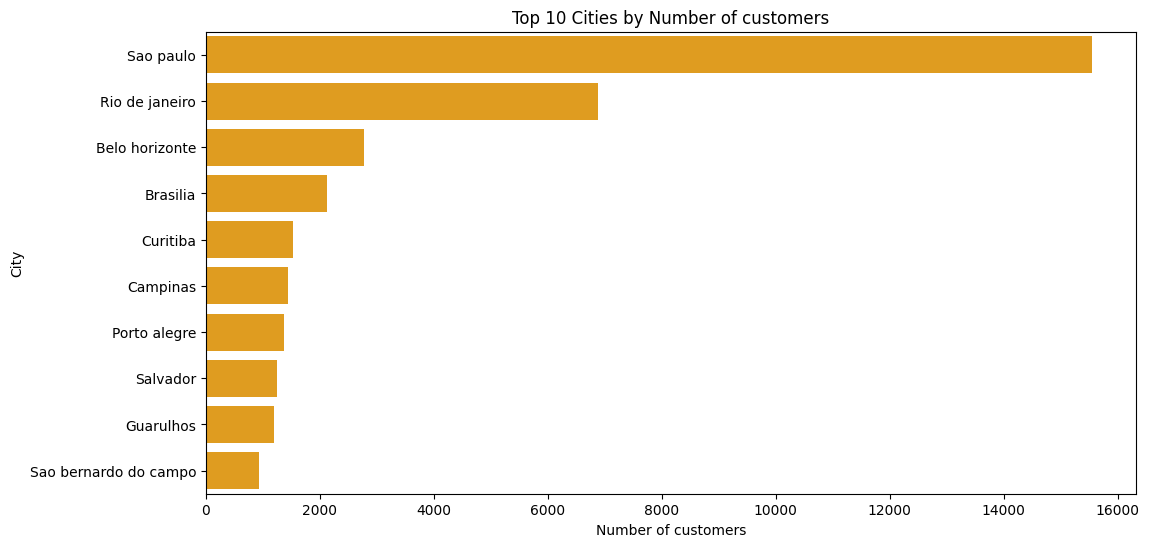

In [166]:
top_cities = customers['customer_city'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_cities.values, y=top_cities.index,  color = 'orange')

plt.title("Top 10 Cities by Number of customers",)
plt.xlabel("Number of customers")
plt.ylabel("City")
plt.show()

# majority of customers are from Sao Paulo, followed by Rio de Janeiro and Belo Horizonte,
#  which is consistent with the distribution of sellers and suggests that these cities are key markets for e-commerce in Brazil.

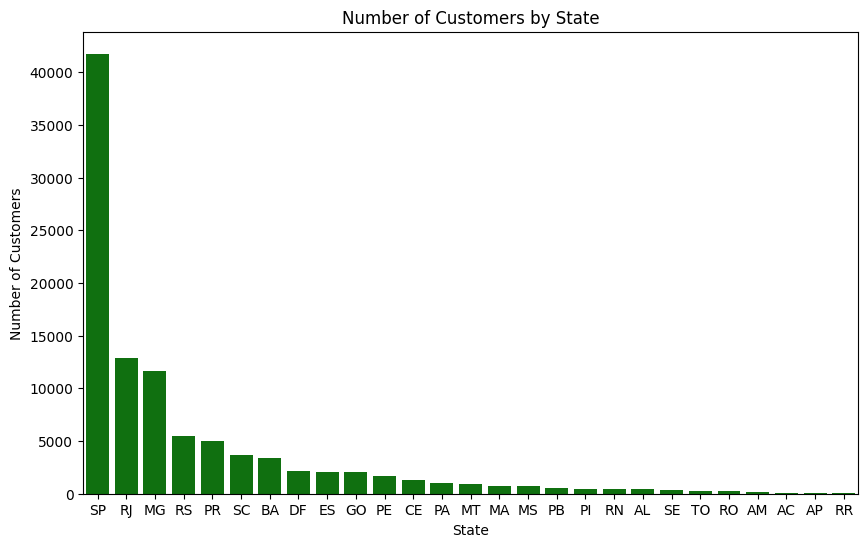

In [167]:
customers_state_count = customers['customer_state'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=customers_state_count.index, y=customers_state_count.values, color = 'green')

plt.title("Number of Customers by State")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.show()

# Sellers are mostly concentrated in SP, followed by MG and RJ, which could indicate regional hubs for e-commerce activity in Brazil.


Conclusion:
About 97% of customers are unique, indicating that repeat purchases are relatively low, with only around 3% customer retention. The highest number of customers come from the cities São Paulo, Rio de Janeiro, and Belo Horizonte, while the top states include SP, RJ, and MG. This suggests that these regions represent the primary target market areas for the business.

geo location table

In [168]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,Sao paulo,SP
1,1046,-23.546081,-46.644820,Sao paulo,SP
2,1046,-23.546129,-46.642951,Sao paulo,SP
3,1041,-23.544392,-46.639499,Sao paulo,SP
4,1035,-23.541578,-46.641607,Sao paulo,SP


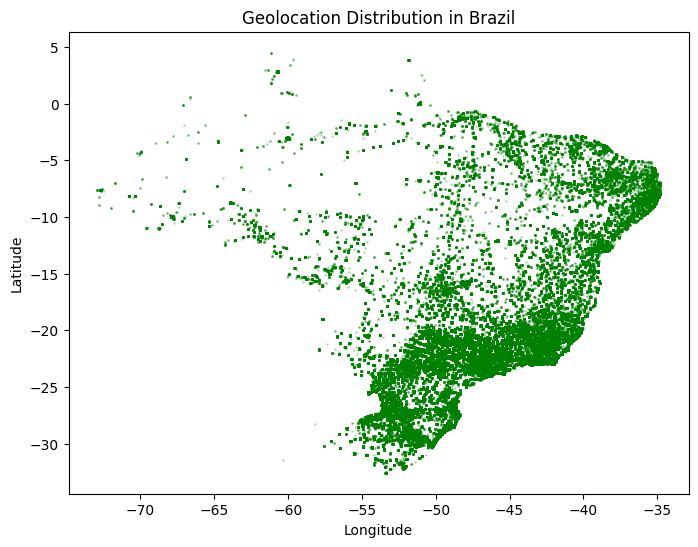

In [169]:
plt.figure(figsize=(8,6))

plt.scatter(geolocation['geolocation_lng'],geolocation['geolocation_lat'],alpha=0.2,s=1, color = 'green')

plt.title("Geolocation Distribution in Brazil")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

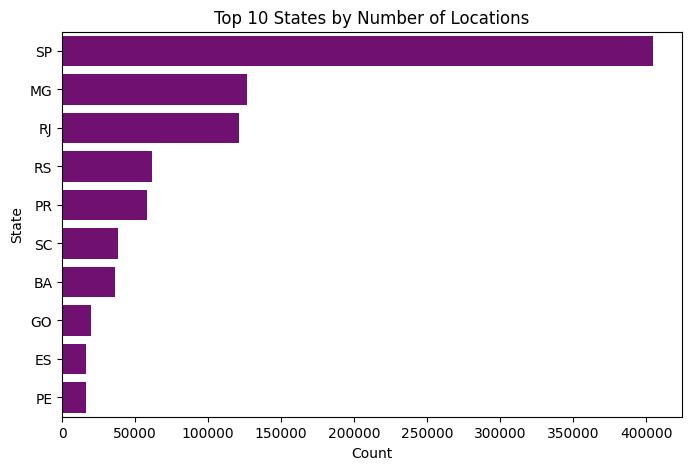

In [170]:
state_counts = geolocation['geolocation_state'].value_counts().head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    x=state_counts.values,
    y=state_counts.index, color = 'purple')

plt.title("Top 10 States by Number of Locations")
plt.xlabel("Count")
plt.ylabel("State")

plt.show()

In [171]:
import folium
from folium.plugins import MarkerCluster

# sample points (dataset is large)
sample_geo = geolocation.sample(2000)

m = folium.Map(location=[-14.2, -51.9], zoom_start=4)

marker_cluster = MarkerCluster().add_to(m)

for idx, row in sample_geo.iterrows():
    folium.Marker(
        location=[row['geolocation_lat'], row['geolocation_lng']]
    ).add_to(marker_cluster)

m


Conclusion:
The geolocation analysis shows that most locations are concentrated in the southeastern region of Brazil, particularly in São Paulo (SP), Rio de Janeiro (RJ), and Minas Gerais (MG). The geographic distribution indicates that the majority of platform activity occurs in highly urbanized areas.

Performing detailed EDA for better insights

In [232]:
# merging dataframes

payment_details = orders.merge(order_payments, on='order_id', how='left')
payment_details = pd.merge(payment_details, customers, on='customer_id', how='left')


product_analysis_df = order_items.merge(products,on='product_id',how='outer').merge(orders,on='order_id',how='left').merge(
    category_translation, on = 'product_category_name', how = 'left').merge(customers, on='customer_id', how='left')

seller_analysis_df = order_items.merge(
    sellers,on='seller_id',how='left').merge(
    orders,on='order_id', how='left')

review_analysis_df= (
    orders
    .merge(customers[['customer_id', 'customer_city', 'customer_state']], on='customer_id', how='left')
    .merge(order_items[['order_id', 'product_id']], on='order_id', how='left')
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')
    .merge(order_reviews[['order_id', 'review_score','review_category']], on='order_id', how='left')
)

In [221]:
payment_details.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,order_estimated_delivery_time,...,day_of_week,payment_sequential,payment_type,payment_installments,payment_value,payment_size,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8 days 10:28:40,15 days 13:03:27,...,Monday,1.0,credit_card,1.0,18.12,Small,7c396fd4830fd04220f754e42b4e5bff,3149,Sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8 days 10:28:40,15 days 13:03:27,...,Monday,3.0,voucher,1.0,2.00,Small,7c396fd4830fd04220f754e42b4e5bff,3149,Sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8 days 10:28:40,15 days 13:03:27,...,Monday,2.0,voucher,1.0,18.59,Small,7c396fd4830fd04220f754e42b4e5bff,3149,Sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13 days 18:46:08,19 days 03:18:23,...,Tuesday,1.0,boleto,1.0,141.46,Small,af07308b275d755c9edb36a90c618231,47813,Barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 09:27:40,26 days 15:21:11,...,Wednesday,1.0,credit_card,3.0,179.12,Small,3a653a41f6f9fc3d2a113cf8398680e8,75265,Vianopolis,GO


In [174]:
payment_details.info()

<class 'pandas.DataFrame'>
RangeIndex: 103887 entries, 0 to 103886
Data columns (total 28 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       103887 non-null  str            
 1   customer_id                    103887 non-null  str            
 2   order_status                   103887 non-null  str            
 3   order_purchase_timestamp       103887 non-null  datetime64[us] 
 4   order_approved_at              103712 non-null  datetime64[us] 
 5   order_delivered_carrier_date   101999 non-null  datetime64[us] 
 6   order_delivered_customer_date  100755 non-null  datetime64[us] 
 7   order_estimated_delivery_date  103887 non-null  datetime64[us] 
 8   delivery_time                  100755 non-null  timedelta64[us]
 9   order_estimated_delivery_time  103887 non-null  timedelta64[us]
 10  order_shipping_time            101985 non-null  timedelta64[us]
 11

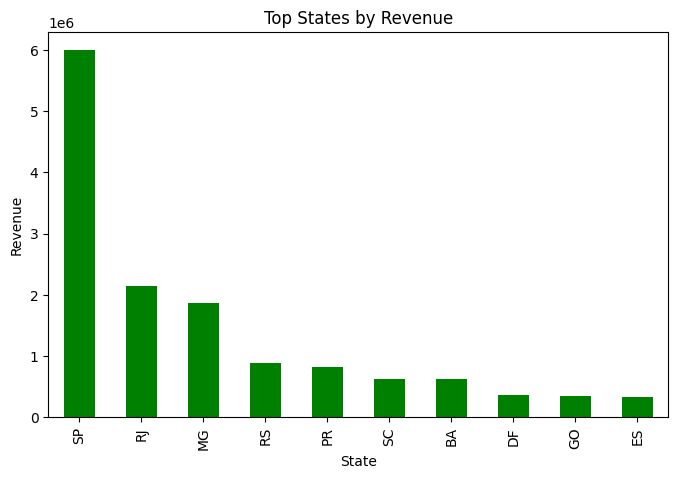

In [175]:
state_revenue = payment_details.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)

state_revenue.head(10).plot(kind='bar', figsize=(8,5), color = 'green')

plt.title("Top States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

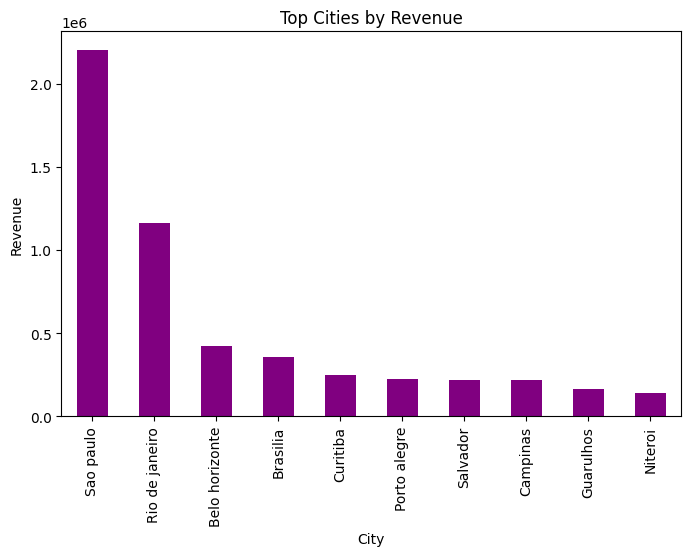

In [204]:
state_revenue = payment_details.groupby('customer_city')['payment_value'].sum().sort_values(ascending=False)

state_revenue.head(10).plot(kind='bar', figsize=(8,5), color = 'purple')

plt.title("Top Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.show()

States like SP, RJ, and MG generate the highest revenue, indicating that most customers are concentrated in Brazil’s southeastern region. Also Sao paulo, Rio de janeiro generates the highest revenue.

In [206]:
# Revenue per year
payment_details['order_year'] = payment_details['order_purchase_timestamp'].dt.year
revenue_year = payment_details.groupby('order_year')['payment_value'].sum()
revenue_year                                                                                                          

order_year
2016      59362.34
2017    7249746.73
2018    8699763.05
Name: payment_value, dtype: float64

In [207]:
revenue_growth_pct = ((revenue_year.loc[2018] - revenue_year.loc[2017]) / revenue_year.loc[2017]) * 100
revenue_growth_pct

20.00092381158259

 Revenue increased significantly from 2017 to 2018, growing by approximately 20%, indicating strong expansion of the platform during this period.
2016 revenue is very small because the dataset only contains a few months of 2016 data, so comparisons should mainly focus on 2017 vs 2018.

Text(0, 0.5, 'Total Revenue')

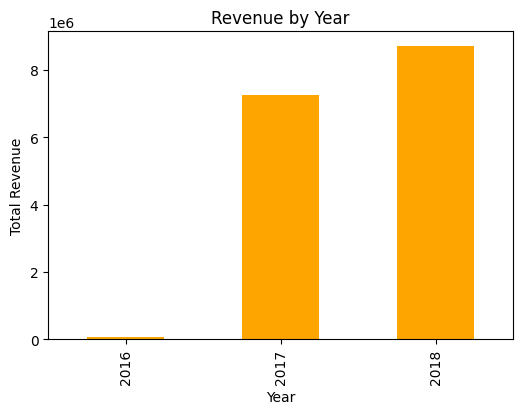

In [177]:
payment_details['order_year'] = payment_details['order_purchase_timestamp'].dt.year
revenue_year = payment_details.groupby('order_year')['payment_value'].sum()

revenue_year.plot(kind='bar', figsize=(6,4), color = 'orange')

plt.title("Revenue by Year")
plt.xlabel("Year")
plt.ylabel("Total Revenue")

# Revenue increased significantly in 2018 compared to 2017.

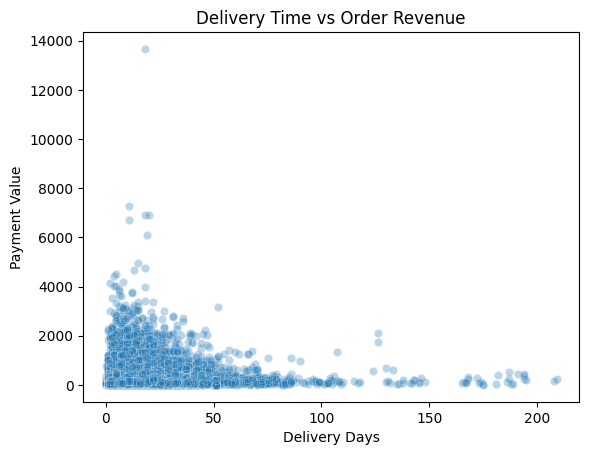

In [178]:
sns.scatterplot(
    x=payment_details['delivery_time'].dt.days,
    y=payment_details['payment_value'],
    alpha=0.3)

plt.title("Delivery Time vs Order Revenue")
plt.xlabel("Delivery Days")
plt.ylabel("Payment Value")

plt.show()

The scatter plot shows the relationship between delivery time (in days) and order revenue. Most orders are delivered within 5–20 days, and the majority of transactions fall under 500 BRL. The plot does not show a strong correlation between delivery time and order value, indicating that both low-value and high-value orders experience similar delivery durations. A few high-revenue outliers exist, but overall delivery time appears relatively consistent across different order values.

In [179]:
product_analysis_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_value,freight_ratio,product_category_name,...,is_canceled,approval_time,delivery_delay,purchase_month,day_of_week,product_category_name_english_y,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,f30149f4a8882a08895b6a242aa0d612,1,00066f42aeeb9f3007548bb9d3f33c38,5670f4db5b62c43d542e1b2d56b0cf7c,2018-05-24 18:58:59,101.65,18.59,120.24,18.288244,perfumaria,...,False,0.227222,-14.0,2018-05,Sunday,perfumery,cd929c5ecff5fc60e9d808d33702e434,95890,Teutonia,RS
1,f5eda0ded77c1293b04c953138c8331d,1,00088930e925c41fd95ebfe695fd2655,7142540dd4c91e2237acb7e911c4eba2,2017-12-18 19:32:19,129.90,13.93,143.83,10.723634,automotivo,...,False,0.197500,-13.0,2017-12,Tuesday,auto,cbbeff6b693e69511cf9d059f4b71036,14403,Franca,SP
2,0bf736fd0fd5169d60de3699fcbcf986,1,0009406fd7479715e4bef61dd91f2462,4a3ca9315b744ce9f8e9374361493884,2017-12-29 16:12:36,229.00,13.10,242.10,5.720524,cama_mesa_banho,...,False,25.161111,-10.0,2017-12,Thursday,bed_bath_table,f51fb63558e88eb3373773d106fa6880,2883,Sao paulo,SP
3,3aba44d8e554ab4bb8c09f6f78032ca8,1,000b8f95fcb9e0096488278317764d19,40ec8ab6cdafbcc4f544da38c67da39a,2018-08-16 13:35:21,58.90,19.60,78.50,33.276740,utilidades_domesticas,...,False,0.179444,-10.0,2018-08,Friday,housewares,4e32da06df703a2561f63e75b13f6260,95174,Farroupilha,RS
4,6f0dfb5b5398b271cc6bbd9ee263530e,1,000b8f95fcb9e0096488278317764d19,40ec8ab6cdafbcc4f544da38c67da39a,2018-08-07 22:15:19,58.90,19.60,78.50,33.276740,utilidades_domesticas,...,False,0.246111,-17.0,2018-08,Wednesday,housewares,7f2dfd48dba158dbf61ba2ea631d93df,93530,Novo hamburgo,RS


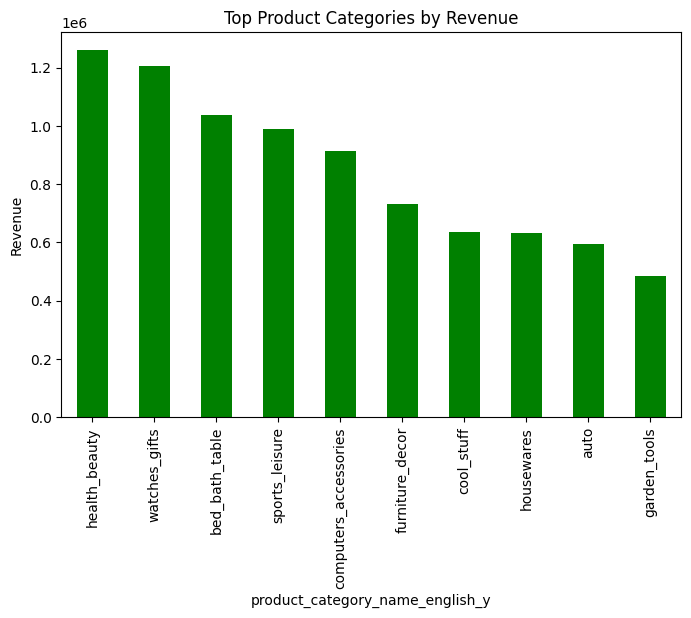

In [180]:
# Top 10 product categories by revenue

category_revenue = product_analysis_df.groupby('product_category_name_english_y')['price'].sum().sort_values(ascending=False)

top_revenue_categories = category_revenue.head(10)

top_revenue_categories.plot(kind='bar', figsize=(8,5), color = 'green')

plt.title("Top Product Categories by Revenue")
plt.ylabel("Revenue")

plt.show()


In [ ]:
# Top 10 most expensive products

product_analysis_df[['product_id', 'product_category_name_english_y', 'price']].sort_values(by='price', ascending=False).head(10)

,product_id,product_category_name_english_y,price
32785,489ae2aa008f021502940f251d4cce7f,housewares,6735.00
47640,69c590f7ffc7bf8db97190b6cb6ed62e,computers,6729.00
12240,1bdf5e6731585cf01aa8169c7028d6ad,art,6499.00
73345,a6492cc69376c469ab6f61d8f44de961,small_appliances,4799.00
86226,c3ed642d592594bb648ff4a04cee2747,small_appliances,4690.00
16145,259037a6a41845e455183f89c5035f18,computers,4590.00
71272,a1beef8f3992dbd4cd8726796aa69c53,musical_instruments,4399.87
49149,6cdf8fc1d741c76586d8b6b15e9eef30,consoles_games,4099.99
97475,dd113cb02b2af9c8e5787e8f1f0722f6,sports_leisure,4059.00
47397,6902c1962dd19d540807d0ab8fade5c6,watches_gifts,3999.90


In [182]:
city_freight = product_analysis_df.groupby('customer_city')['freight_value'].sum().sort_values(ascending=False)

city_freight.head(10)

customer_city
Sao paulo         255302.58
Rio de janeiro    161695.16
Belo horizonte     61122.26
Brasilia           50384.89
Salvador           35667.98
Porto alegre       33502.01
Curitiba           33001.81
Campinas           24697.17
Fortaleza          20778.01
Recife             20220.51
Name: freight_value, dtype: float64

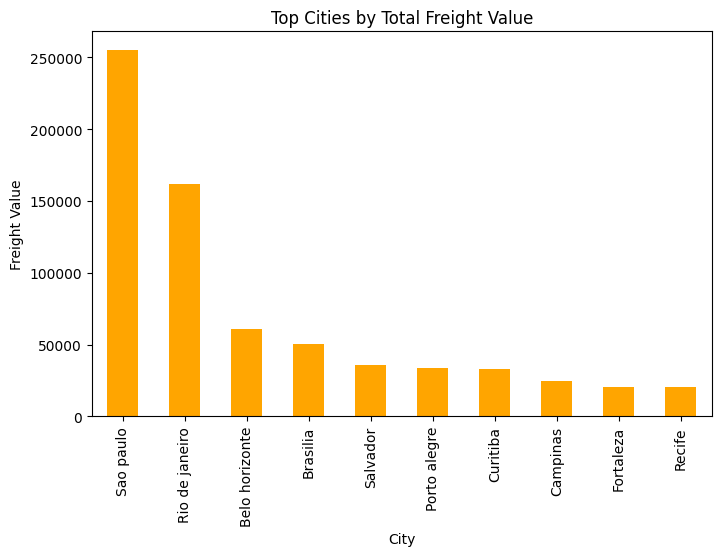

In [183]:
city_freight.head(10).plot(kind='bar', figsize=(8,5), color = 'orange')

plt.title("Top Cities by Total Freight Value")
plt.xlabel("City")
plt.ylabel("Freight Value")

plt.show()

The city-level analysis shows a similar pattern to the city-level revenue analysis. Major cities such as São Paulo, Rio de Janeiro, and Belo Horizonte dominate total sales value, which is expected since these cities are located in the states with the highest revenue.

In [ ]:
# Top 10 product categories by average freight cost

freight_category = product_analysis_df.groupby(
    'product_category_name_english_y'
)['freight_value'].mean().sort_values(ascending=False)

freight_category.head(10)

product_category_name_english_y
computers                                  48.454680
home_appliances_2                          44.538571
furniture_mattress_and_upholstery          42.906842
kitchen_dining_laundry_garden_furniture    42.702598
furniture_bedroom                          42.497523
office_furniture                           40.551124
small_appliances_home_oven_and_coffee      36.156053
furniture_living_room                      35.722008
signaling_and_security                     32.702613
industry_commerce_and_business             29.420448
Name: freight_value, dtype: float64

In [191]:
seller_analysis_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_value,freight_ratio,seller_zip_code_prefix,...,order_estimated_delivery_time,order_shipping_time,order_processing_time,order_transit_time,is_delivered,is_canceled,approval_time,delivery_delay,purchase_month,day_of_week
0,7f39ba4c9052be115350065d07583cac,1,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-24 23:56:20,895.0,21.02,916.02,2.348603,9080,...,21 days 15:43:26,1 days 14:32:41,0 days 15:39:46,7 days 02:17:04,True,False,15.662778,-13.0,2017-10,Wednesday
1,9dc8d1a6f16f1b89874c29c9d8d30447,1,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-18 14:49:22,895.0,21.02,916.02,2.348603,9080,...,24 days 10:26:38,5 days 01:53:20,0 days 00:16:00,7 days 04:35:02,True,False,0.266667,-13.0,2017-10,Thursday
2,d455a8cb295653b55abda06d434ab492,1,a2ff5a97bf95719e38ea2e3b4105bce8,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-12 22:24:16,895.0,21.02,916.02,2.348603,9080,...,33 days 01:42:55,1 days 17:28:47,1 days 00:07:11,8 days 00:19:44,True,False,24.119722,-23.0,2017-09,Tuesday
3,006e43460a55bc60c0a437521e426529,1,08574b074924071f4e201e151b152b4e,001cca7ae9ae17fb1caed9dfb1094831,2017-05-17 01:30:22,99.0,43.06,142.06,43.494949,29156,...,21 days 23:35:25,1 days 10:56:10,0 days 01:05:47,6 days 21:24:45,True,False,1.096389,-14.0,2017-05,Thursday
4,00dfb074b5c910fbd08e04691c4b712f,1,4f3b83b83f7fb280fca4f90ba502f50e,001cca7ae9ae17fb1caed9dfb1094831,2017-06-19 19:55:19,99.5,35.07,134.57,35.246231,29156,...,31 days 04:16:25,0 days 19:17:22,0 days 00:11:44,5 days 17:51:18,True,False,0.195556,-25.0,2017-06,Thursday


In [186]:
# Top 10 sellers by revenue

top_sellers_revenue = seller_analysis_df.groupby('seller_id')['price'].sum().sort_values(ascending=False)

top_sellers_revenue.head(10)

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

In [ ]:
# Top 10 sellers by number of orders

seller_orders = seller_analysis_df.groupby('seller_id')['order_id'].nunique().sort_values(ascending=False)

seller_orders.head(10)

seller_id
6560211a19b47992c3666cc44a7e94c0    1854
4a3ca9315b744ce9f8e9374361493884    1806
cc419e0650a3c5ba77189a1882b7556a    1706
1f50f920176fa81dab994f9023523100    1404
da8622b14eb17ae2831f4ac5b9dab84a    1314
955fee9216a65b617aa5c0531780ce60    1287
7a67c85e85bb2ce8582c35f2203ad736    1160
ea8482cd71df3c1969d7b9473ff13abc    1146
4869f7a5dfa277a7dca6462dcf3b52b2    1132
3d871de0142ce09b7081e2b9d1733cb1    1080
Name: order_id, dtype: int64

In [ ]:
seller_status = seller_analysis_df.groupby(['seller_id','order_status', '']).size().unstack()

seller_status.head()

order_status,approved,canceled,delivered,invoiced,processing,shipped,unavailable
seller_id,,,,,,,
0015a82c2db000af6aaaf3ae2ecb0532,NaN,NaN,3.0,NaN,NaN,NaN,NaN
001cca7ae9ae17fb1caed9dfb1094831,NaN,NaN,234.0,NaN,NaN,5.0,NaN
001e6ad469a905060d959994f1b41e4f,NaN,1.0,NaN,NaN,NaN,NaN,NaN
002100f778ceb8431b7a1020ff7ab48f,NaN,NaN,54.0,NaN,NaN,1.0,NaN
003554e2dce176b5555353e4f3555ac8,NaN,NaN,1.0,NaN,NaN,NaN,NaN


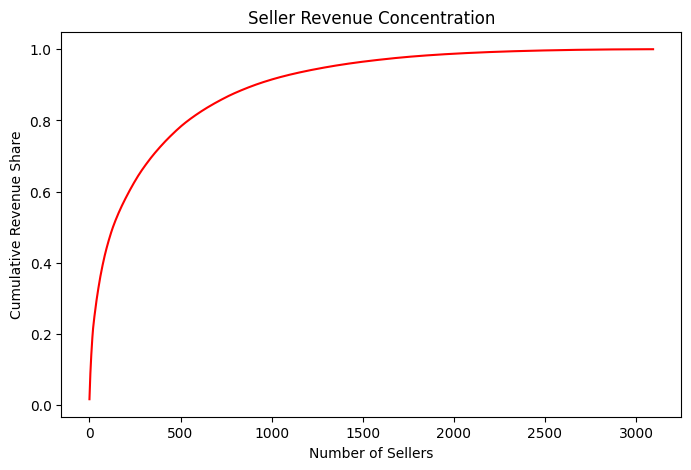

In [196]:
seller_revenue = seller_analysis_df.groupby('seller_id')['price'].sum().sort_values(ascending=False)

seller_revenue_cumsum = seller_revenue.cumsum() / seller_revenue.sum()



plt.figure(figsize=(8,5))

plt.plot(seller_revenue_cumsum.values, color = 'red')

plt.title("Seller Revenue Concentration")
plt.xlabel("Number of Sellers")
plt.ylabel("Cumulative Revenue Share")

plt.show()

A small proportion of sellers generate a large share of the total revenue. The steep rise at the beginning of the cumulative revenue curve indicates strong revenue concentration, where top-performing sellers dominate the marketplace sales while the majority of sellers contribute relatively smaller portions of revenue.

In [ ]:
# top 10 fastest delivering sellers

seller_analysis_df['delivery_time'] = (
    seller_analysis_df['order_delivered_customer_date'] -
    seller_analysis_df['order_purchase_timestamp']
).dt.days

seller_delivery = seller_analysis_df.groupby('seller_id')['delivery_time'].mean().sort_values()

seller_delivery.head(10)


seller_id
139157dd4daa45c25b0807ffff348363    1.0
6561d6bf844e464b4019442692b40e02    1.0
f3511c85f59f8dec53d140501ee8e7a8    1.0
5e063e85d44b0f5c3e6ec3131103a57e    1.0
96f7c797de9ca20efbe14545bed63eec    1.0
751e274377499a8503fd6243ad9c56f6    1.0
2c00c85d30361cd2ced2969cffbbffa3    1.0
702835e4b785b67a084280efca355756    1.0
674207551483fec113276b67b0d871ff    1.0
734def04b237117a09321dd6d8f3f2a2    1.5
Name: delivery_time, dtype: float64

In [198]:
seller_freight_ratio = seller_analysis_df.groupby('seller_id').apply(
    lambda x: x['freight_value'].sum() / x['price'].sum()
)

seller_freight_ratio.sort_values(ascending=False).head(10)

seller_id
3d62f86afa7c73be2628a3be1423f5a0    3.535000
cf6f6bc4df3999b9c6440f124fb2f687    2.491429
0f94588695d71662beec8d883ffacf09    2.065556
80146bc52c4f6af5239b23de2a20262b    1.833210
95cca791657aabeff15a07eb152d7841    1.824825
34aefe746cd81b7f3b23253ea28bef39    1.815000
43753b27d77860f1654aa72e251a7878    1.773222
bb7ad8a45c027be8ab075b8e465f8ca0    1.633634
a61cc04793308395a840807104365121    1.622693
344223b2a90784f64136a8a5da012e7f    1.540367
dtype: float64

Some sellers incur significantly higher shipping costs relative to product value.

In [233]:
review_analysis_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,order_estimated_delivery_time,...,approval_time,delivery_delay,purchase_month,day_of_week,customer_city,customer_state,product_id,product_category_name_english,review_score,review_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8 days 10:28:40,15 days 13:03:27,...,0.178333,-8.0,2017-10,Monday,Sao paulo,SP,87285b34884572647811a353c7ac498a,housewares,4.0,Good
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13 days 18:46:08,19 days 03:18:23,...,30.713889,-6.0,2018-07,Tuesday,Barreiras,BA,595fac2a385ac33a80bd5114aec74eb8,perfumery,4.0,Good
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9 days 09:27:40,26 days 15:21:11,...,0.276111,-18.0,2018-08,Wednesday,Vianopolis,GO,aa4383b373c6aca5d8797843e5594415,auto,5.0,Very Good
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13 days 05:00:36,26 days 04:31:54,...,0.298056,-13.0,2017-11,Saturday,Sao goncalo do amarante,RN,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,5.0,Very Good
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2 days 20:58:23,12 days 02:41:21,...,1.030556,-10.0,2018-02,Tuesday,Santo andre,SP,65266b2da20d04dbe00c5c2d3bb7859e,stationery,5.0,Very Good


In [ ]:
# Top 10 product categories by number of reviews

category_review_counts = review_analysis_df.groupby('product_category_name_english')['review_score'].count()

category_review_counts_sorted = category_review_counts.sort_values(ascending=False)

print("Top product categories by number of reviews:")
print(category_review_counts_sorted.head(10))

Top product categories by number of reviews:
product_category_name_english
bed_bath_table           11137
health_beauty             9645
sports_leisure            8640
furniture_decor           8331
computers_accessories     7849
housewares                6943
watches_gifts             5950
telephony                 4517
garden_tools              4329
auto                      4213
Name: review_score, dtype: int64


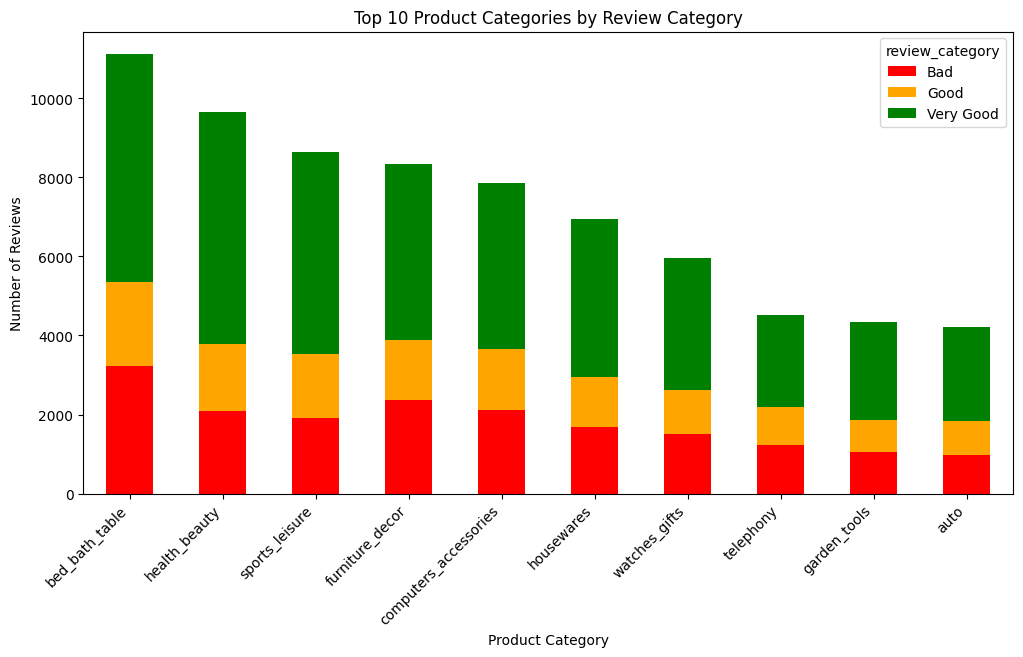

In [ ]:
category_review_counts = pd.crosstab(
    review_analysis_df['product_category_name_english'],
    review_analysis_df['review_category']           
)

top_categories = category_review_counts.sum(axis=1).sort_values(ascending=False).head(10)
category_review_counts_top = category_review_counts.loc[top_categories.index]

# Plot stacked bar chart
category_review_counts_top.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12,6), 
    color=['red', 'orange', 'green']  
)

plt.title("Top 10 Product Categories by Review Category")
plt.ylabel("Number of Reviews")
plt.xlabel("Product Category")
plt.xticks(rotation=45, ha='right')
plt.show()

Most of the top product categories receive a significantly higher number of “Very Good” reviews compared to “Good” and “Bad” reviews, indicating overall positive customer satisfaction. Categories such as bed_bath_table, health_beauty, and sports_leisure not only generate the highest number of reviews but also maintain a strong proportion of positive feedback.

Key Insights :

Product Pricing:
Product pricing is represented in the form of a right-skewed distribution, implying that the majority of the products are priced lower (i.e., lower than 200 BRL), while very few products are expensive.

Shipping Costs:
The values of freight costs are significantly lower compared to the product pricing. The majority of the freight costs lie within the range of 10-40 BRL. In some cases, the freight costs are higher compared to the product pricing, mostly for lower-priced products.

Order Value:
The distribution of the total order value is also right-skewed, implying that the majority of the orders are lower or moderate in value, while a very few orders are generating high payment value(may have bulk orders), indicating most revenue generating orders have low payment value. 

Marketplace Sales Structure:
A small number of sellers are responsible for the majority of the revenue generated in the marketplace.

Order Behavior:
Most orders contain only one item, implying that customers are purchasing individual items rather than multiple items at once.

Payment Patterns:
The majority of the customers are using credit cards for transactions, and the installment payment option is also being utilized frequently, implying that the flexible payment options are influencing the purchasing decisions of the customers.

Delivery Performance:
Most orders are being delivered, implying that the order fulfillment, but some orders took over 60 days to deliver, indicating the need of logistic improvement.

Customer Retention:
The level of customer retention seems very low, as around 97% of the customers have made only one purchase, while only around 3% of the customers have made repeat purchases. This indicates that the marketplace is relying on new customer purchases.

Top Product Categories:
It seems that some of the product categories have a significant level of dominance in the marketplace. Product categories like bed, bath, and table, health and beauty, and sports and leisure have the highest number of orders.

Geographical Distribution of Orders:
The orders are concentrated in the major cities. The major cities that are responsible for the highest number of orders are São Paulo, Rio de Janeiro, and Belo Horizonte.
At the state level, the top three states are São Paulo, Rio de Janeiro, and Minas Gerais. Hence, the sales are concentrated in the major economic regions of Brazil.

Overall conclosion:
Overall, the marketplace is dominated by low-value transactions and high-value contributors. The same is true for the number of sellers and the number of products. The sales are concentrated in the major regions of Brazil.

